In [82]:
import numpy as np
import time
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

In [29]:
num_states_min, num_states_max = 2, 5
def get_num_states(num_states_min, num_states_max):
    return num_states_min + np.random.randint((num_states_max + 1 - num_states_min))

In [31]:
for i in range(5):
    num_states = get_num_states(num_states_min, num_states_max)
    ! ../genRandPFSA -a 2 -n {num_states} -p ../baseChoice_cfgfiles/PFSA_{i}.cfg
    time.sleep(1)

In [64]:
def separation(D, labels):
    dim = len(D)
    A, B = 0, 0
    ca, cb = 0, 0
    for i in range(dim):
        for j in range(dim):
            k, l = labels[i], labels[j]
            if k == l:
                A += D[i][j]
                ca += 1
            else:
                B += D[i][j]
                cb += 1
    return (A / ca) / (B / cb)

#------------------------------A test of validity--------------------------
n1, n2 = 5, 5
std1, std2 = .2, .2 # the smaller the stds the smaller the separation 
labels = [0] * n1 + [1] * n2
X1 = np.array([-1, -1]) + std1 * np.random.randn(n1, 2)
X2 = np.array([1, 1]) + std2 * np.random.randn(n2, 2)
X = np.vstack((X1, X2))
D = distance_matrix(X, X)
separation(D, labels)

0.09651168218595016

In [100]:
! cat ../seqDatasets/seq_1.dat ../seqDatasets/seq_2.dat > seq.dat

In [101]:
! ../bin/lsmash -h

### Loglikelihood zed.uchicago.edu 2018 ###
--------------------------
Example Usage:
../bin/lsmash -f seq.dat
../bin/lsmash -f seq.dat -x 100 (restrict length of data read)
../bin/lsmash -f seq.dat -x 100 -o L.dst (specify output file)
../bin/lsmash -F S2.cfg M2.cfg T3.cfg -f seq.dat -x 100 (specify PFSA projectors)
 Usage:
  -h [ --help ]               print help message.
  -V [ --version ]            print version number
  -f [ --seq ] arg            input sequence file
  -D [ --datadir ] arg        data direction: row or column [row]
  -T [ --datatype ] arg       data type: continous or symbolic
  -x [ --datalen ] arg        length max for input sequence [10000000]
  -P [ --partition ] arg      partition
  -u [ --use_derivative ] arg use derivative [false]
  -F [ --pfsafile ] arg       pfsa files
  -t [ --timer ] arg          display timer [0 (false)] 
  -S [ --sae ] arg            use data smash for sae [1 (true)] 
  -n [ --numrepeat ] arg      repeat for sae [20] 
  -o [ --dfile 

In [102]:
! ../bin/lsmash -f seq.dat -T symbolic -o lsmash.dst -S 0 -F ../baseChoice_cfgfiles/PFSA_0.cfg ../baseChoice_cfgfiles/PFSA_1.cfg

In [103]:
dist = np.genfromtxt('lsmash.dst')
labels = [0] * 25 + [1] * 25
sep = separation(dist, labels)
print(sep)

0.20308842406817013


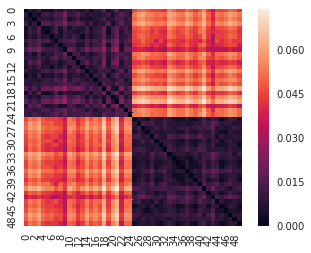

In [104]:
plt.figure()
plt.gca().set_aspect('equal')
sns.heatmap(dist)
plt.show()

In [94]:
labels = [0] * 25 + [1] * 25
num_runs = 100

seps_lsmash, seps_random = [], []
for r in range(num_runs):
    i = np.random.randint(100) + 1
    j = np.random.randint(100) + 1

    ! cat ../seqDatasets/seq_{i}.dat ../seqDatasets/seq_{j}.dat > seq.dat
    ! ../bin/lsmash -f seq.dat -T symbolic -o lsmash.dst -S 0
    ! ../bin/lsmash -f seq.dat -T symbolic -o random.dst -S 0 -F ../baseChoice_cfgfiles/
    dist_lsmash = np.genfromtxt('lsmash.dst')
    dist_random = np.genfromtxt('random.dst')
    sep_lsmash = separation(dist_lsmash, labels)
    sep_random = separation(dist_random, labels)
    seps_lsmash.append(sep_lsmash)
    seps_random.append(sep_random)
        
    print('round {}, ({}, {}), lsmash = {}, random={}'.format(r, i, j, sep_lsmash, sep_random))

round 0, (39, 32), lsmash = 0.14719955767711024, random=0.14719955767711024
round 1, (86, 42), lsmash = 0.5495983794821501, random=0.5495983794821501
round 2, (79, 1), lsmash = 0.13132041521382506, random=0.13132041521382506
round 3, (97, 97), lsmash = 1.0, random=1.0
round 4, (100, 21), lsmash = 0.06764623436634783, random=0.06764623436634783
round 5, (88, 8), lsmash = 0.6039572694456206, random=0.6039572694456206
round 6, (65, 83), lsmash = 0.23182623254540327, random=0.23182623254540327
round 7, (74, 84), lsmash = 0.3627919659497999, random=0.3627919659497999
round 8, (94, 83), lsmash = 0.12958732434255868, random=0.12958732434255868
round 9, (69, 93), lsmash = 0.17155665967843006, random=0.17155665967843006
round 10, (84, 69), lsmash = 0.1802207575390127, random=0.1802207575390127
round 11, (61, 98), lsmash = 0.14991033567923345, random=0.14991033567923345
round 12, (60, 45), lsmash = 0.12806308357168292, random=0.12806308357168292
round 13, (52, 11), lsmash = 0.12301443602646697, 

ZeroDivisionError: division by zero